## **Laboratorio 8: Descenso de Gradiente y Método de Newton**

**Facultad de ingeniería**

Departamento de Ingeniería Biomédica

Universidad de los Andes

**IBIO-2340** Fundamentos de Machine Learning.

**Nombres de los integrantes**

1.   Juan Pablo Castro
2.   Santiago Casasbuenas
3.   Ana Cristina Rodríguez

**Número del grupo**

*9*

# **Método de Newton**

El *Método de Newton*, al igual que el algoritmo de Descenso de Gradiente, es un método de búsqueda de línea utilizado para encontrar el mínimo de un campo escalar $f: \mathbb{R^n} \rightarrow \mathbb{R}$ definido por la expresión iterativa:

$$
x_{n+1} = x_{n} - ( \nabla ^{2} f_{k} )^{-1} \nabla f_{k}
$$

Bajo esta alternativa, aproximamos $f$ a una forma cuadrática en una región cercana al mínimo de la función. Conforme mejor se adapte la función objetivo a una forma cuadrática, más preciso será el mínimo hallado. Note que en esta expresión no aparece la tasa de aprendizaje $\alpha$, en general, las implementaciones del método de Newton asumen $\alpha = 1$.

A diferencia del Descenso de Gradiente, el Método de Newton utiliza la dirección dada por el producto de la inversa de la matriz Hessiana con el gradiente de la función para hallar el mínimo. Esto le permite aprovechar información de la curvatura de $f$, logrando, en muchos casos, una convergencia más rápida.

**1. Algoritmo del Método de Newton**

Veamos paso a paso como opera el algoritmo:

0. **Definimos una tolerancia $ϵ$ y un número máximo de iteraciones $N_{max}$**: La tolerancia nos ayuda a definir la precisión que se quiere alcanzar durante la búsqueda. El número máximo de iteraciones es un límite que evita que el algoritmo se quede estancado en un ciclo indeterminado y pueda ocasionar daños al procesador. Al cumplirse este límite el algoritmo debe detenerse inmediatamente.

1. **Iniciamos desde un punto de partida ($x_0$)**: Este punto inicial es arbitrario, un punto cualquiera en el dominio de la función. Su elección se hace crítica cuando la función no es convexa o tiene varios mínimos locales.

2. **Calculamos el gradiente y la matriz Hessiana para la función en este punto $\nabla_f(x_{0}), \nabla^{2} f(x_{0})$**: Calculamos el vector gradiente de la función objetivo $\nabla_{f}$ y su matriz Hessiana $\nabla^{2} f$ y los evaluamos en el punto de partida $\nabla_{f}(x_{0})$ y $\nabla^{2} f(x_{0})$.

3. **Calculamos la inversa de la matriz Hessiana $(\nabla^{2} f(x_{0}))^{-1}$**: Para esto debemos asegurarnos que la matriz Hessiana sea invertible lo cual se tiene si es definida positiva. 

4. **Hallamos un nuevo punto inicial ($x_1$)**: Al tomar la diferencia $x_0 - ( \nabla ^{2} f(x_0) )^{-1} \nabla f(x_0)$ damos un paso en dirección al mínimo que nos lleva a un nuevo punto $x_1$ que se encuentra más cerca de éste valor. Verificamos la condición de parada $||x_{1} - x_{0}||_2<ϵ$. Si se cumple, entonces tomamos $x_1$ como mínimo, si no continuamos al punto 5:

\begin{align*}
x_{1} = x_{0} - ( \nabla ^{2} f(x_{0}) )^{-1} \nabla f (x_{0})
\end{align*}


5. **Iteramos**: Tomando $x_{1}$ como nuevo punto inicial repetimos el proceso anterior, que continua siguiendo el algoritmo:

\begin{align*}
x_{n+1} = x_{n} -( \nabla ^{2} f(x_{n}) )^{-1} \nabla f(x_{n})
\end{align*}

Hasta que se cumpla la condición de parada $||x_{n+1} - x_{n}||_2<ϵ$. Cuando se cumple finaliza el método y tomamos el último valor $x_{n+1}$ como el mínimo de la función.

**2. Ventajas del Método de Newton**

- **Convergencia rápida**: Cuando la función objetivo es suave, convexa y dos veces diferenciable, el método de Newton converge mucho más rápido que el Descenso de Gradiente.

- **Tasa de Convergencia cuadrática**: Típicamente la tasa de convergencia del método de Newton es cuadrática, lo cual quiere decir que la precisión de la solución mejora exponencialmente en cada iteración.

- **No depende de un Hiperparámetro**: A diferencia del Descenso de Gradiente, el método de Newton aprovecha la información de curvatura de la función, contenida en la matriz Hessiana, para ajustar la dirección y tamaño del paso de búsqueda, lo cual evita problemas de escalado y elimina la necesidad de elegir una tasa de aprendizaje adecuada.

**3. Desventajas del Método de Newton**

- **Alto Costo Computacional**: Calcular la matriz Hessiana y su inversa en cada iteración tiene un costo computacional de $O(n^3)$, en comparación el método de Descenso de Gradiente tiene un costo computacional de $O(n)$. Por lo tanto, el Descenso de Gradiente es mucho más escalable en problemas con grandes cantidades de datos.

- **Depende de forma crítica de la matriz Hessiana**: Si la matriz Hessiana es singular no puede aplicarse directamente el método. Si tiene valores propios muy pequeños o muy grandes (esta mal condicionada) el método se torna inestable, puesto que en las direcciones en las que el gradiente coincida con los autovectores de la matriz Hessiana inversa, los pasos serán muy pequeños o muy grandes haciendo que el algoritmo se estanque, oscile en torno al mínimo o diverja.

- **Funciones Mal comportadas y No Convexas**: Si la función es no convexa, el método de Newton puede converger a un punto de silla en lugar de un mínimo. El método de Newton es ideal para funciones cuadráticas o que localmente sigan un comportamiento cuadrático, funciones con comportamientos distintos pueden requerir de más iteraciones para converger debido a la pérdida de precisión en la aproximación.

# **Introducción al problema**

El centro de atención médica "Los Robles" es una institución de servicios de salud con más de 100 años de trayectoria que se encuentra ubicada en el centro del municipio de San Antonio. Sus empleados, tanto administrativos como personal médico, residen en zonas aledañas al pueblo. Debido al deterioro que ha tenido el edificio durante los 100 años de funcionamiento, el nuevo gerente busca reubicar el centro de salud en una zona que reduzca la distancia de desplazamiento de los empleados sin que se aleje demasiado de la posición actual. Para ello, ha contratado un equipo de ingenieros biomédicos de la Universidad de los Andes, quienes se encargarán de definir la mejor localización para el nuevo centro de salud.

Después de hacer un estudio topográfico, se determinaron las coordenadas de ubicación de la vivienda de los 20 empleados actuales así como las coordenadas de ubicación del actual centro de salud. Esta información se encuentra en el archivo ***localizaciones.csv***. **Las primeras 20 filas en el archivo corresponden a la localización de los empleados y la última es la ubicación actual del centro de salud**.

Para solucionar el problema se debe hallar la ubicación óptima del nuevo centro de salud, el nuevo gerente pide:

* Minimizar el cuadrado de la distancia euclidiana entre cada coordenada de los empleados y la localización del nuevo centro de salud

* Minimizar simultáneamente el cuadrado de la distancia euclidiana entre la nueva y la actual localización del centro de salud.

* Dar una prioridad con un factor de 15 a la minimización de la distancia de los empleados respecto a la minimización de la distancia de la actual ubicación.

No se dispone de restricción alguna respecto a la nueva ubicación del centro de salud. Para facilitar el análisis, sean $p^{(i)}=[p_1^{(i)},p_2^{(i)}]^T$ las coordenadas del $i$-ésimo empleado, $x=[x_1,x_2]^T$ las coordenadas de la nueva ubicación y $q=[q_1,q_2]^T$ las coordenadas de la actual ubicación.

# **Ejercicios**

**1. Formulación Analítica**

**Defina el problema de optimización asociado a los requerimientos de la gerencia del centro de salud: escriba la función objetivo y calcule **analíticamente** el gradiente y la Hessiana.**

Con $p^{(i)} \in \mathbb{R}^2$ (ubicación de los empleados), $x \in \mathbb{R}^2$ (nueva sede) y $q \in \mathbb{R}^2$ (sede actual), la función objetivo con prioridad 15 sobre la distancia a empleados es:

$$f(x)=15\sum_{i=1}^n \|x-p^{(i)}\|_2^2 + \|x-q\|_2^2$$

Su gradiente y Hessiana son:

$$\nabla f(x)=2\left[(15n+1)x-\left(15\sum_{i=1}^n p^{(i)}+q\right)\right]$$

$$\nabla^2 f(x)=2(15n+1)I_2$$

Como $\nabla^2 f(x)$ es definida positiva, el problema es estrictamente convexo y tiene minimizador único.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Markdown

plt.style.use("seaborn-v0_8-whitegrid")


def cargar_localizaciones(path="localizaciones.csv", n_empleados=20, random_seed=2026):
    """Carga coordenadas de empleados y sede actual.
    Si el archivo no existe, genera un conjunto sintetico reproducible para poder ejecutar el notebook.
    """
    ruta = Path(path)
    uso_datos_sinteticos = False

    if ruta.exists():
        coords = None
        for delim in [",", ";", "	", None]:
            try:
                if delim is None:
                    arr = np.genfromtxt(ruta, dtype=float)
                else:
                    arr = np.genfromtxt(ruta, delimiter=delim, dtype=float)
            except Exception:
                continue

            arr = np.atleast_2d(arr)
            if arr.shape[1] < 2:
                continue

            cand = arr[:, :2]
            cand = cand[np.isfinite(cand).all(axis=1)]
            if cand.shape[0] >= n_empleados + 1:
                coords = cand
                break

        if coords is None:
            raise ValueError("No fue posible leer dos columnas numericas validas desde localizaciones.csv")
    else:
        uso_datos_sinteticos = True
        rng = np.random.default_rng(random_seed)
        empleados = rng.normal(loc=[40.0, 35.0], scale=[10.0, 8.0], size=(n_empleados, 2))
        q = np.array([[62.0, 58.0]])
        coords = np.vstack([empleados, q])

    if coords.shape[0] < n_empleados + 1:
        raise ValueError(
            f"Se esperaban al menos {n_empleados + 1} filas con coordenadas y solo se encontraron {coords.shape[0]}."
        )

    coords = coords[: n_empleados + 1]
    empleados = coords[:n_empleados]
    q = coords[n_empleados]
    return empleados, q, uso_datos_sinteticos, ruta


def objetivo(x, P, q, w_emp=15.0, w_q=1.0):
    x = np.asarray(x, dtype=float)
    return w_emp * np.sum((P - x) ** 2) + w_q * np.sum((x - q) ** 2)


def gradiente_objetivo(x, P, q, w_emp=15.0, w_q=1.0):
    x = np.asarray(x, dtype=float)
    n = P.shape[0]
    return 2.0 * (w_emp * (n * x - P.sum(axis=0)) + w_q * (x - q))


def hessiana_objetivo(P, w_emp=15.0, w_q=1.0):
    n = P.shape[0]
    return 2.0 * (w_emp * n + w_q) * np.eye(2)


def minimizador_cerrado(P, q, w_emp=15.0, w_q=1.0):
    n = P.shape[0]
    return (w_emp * P.sum(axis=0) + w_q * q) / (w_emp * n + w_q)


# Datos del problema
P, q, uso_datos_sinteticos, ruta_datos = cargar_localizaciones()
n = P.shape[0]
WE, WQ = 15.0, 1.0
x0 = q.copy()  # punto inicial: ubicacion actual

# Definiciones para los metodos numericos
f_base = lambda x: objetivo(x, P, q, WE, WQ)
g_base = lambda x: gradiente_objetivo(x, P, q, WE, WQ)
H_base = lambda x=None: hessiana_objetivo(P, WE, WQ)

if uso_datos_sinteticos:
    display(Markdown("**Aviso:** No se encontro `localizaciones.csv`. Se generaron datos sinteticos reproducibles solo para demostracion."))
else:
    display(Markdown(f"**Datos cargados correctamente desde:** `{ruta_datos}`"))

x_cerrado = minimizador_cerrado(P, q, WE, WQ)
print("Minimizador analitico (forma cerrada):", np.round(x_cerrado, 6))

**Datos cargados correctamente desde:** `localizaciones.csv`

Minimizador analitico (forma cerrada): [16.914833 24.100398]


**2. Descenso de Gradiente - Configuración**

Implemente el método de Descenso de Gradiente para encontrar la ubicación óptima del nuevo centro de salud. Para ello, utilice al menos tres valores diferentes para la tasa de aprendizaje $\alpha$. Además defina la tolerancia, el criterio de parada y el número máximo de pasos del algoritmo. Justifique su elección.

**Configuración:**
- Tolerancia: $\epsilon = 1 \times 10^{-10}$
- Criterio de parada: $\|\nabla f(x_k)\|_2 \leq \epsilon$ o $\|x_{k+1}-x_k\|_2 \leq \epsilon$
- Número máximo de iteraciones: $N_{\max} = 10000$
- **Justificación:** Para una función cuadrática con Hessiana constante, una guía práctica es usar $\alpha$ alrededor de $1/L$, donde $L=\lambda_{\max}(\nabla^2 f)$. Se prueban valores por debajo, cerca y por encima del límite estable para observar el comportamiento del algoritmo.

In [2]:
def descenso_gradiente(grad_fn, obj_fn, x0, alpha, tol=1e-10, max_iter=10000):
    x = np.asarray(x0, dtype=float).copy()
    trayectoria = [x.copy()]
    convergio = False
    motivo = "max_iter"

    for k in range(1, max_iter + 1):
        g = grad_fn(x)
        grad_norm = np.linalg.norm(g)

        if grad_norm <= tol:
            convergio = True
            motivo = "||grad|| <= tol"
            break

        paso = -alpha * g
        x_nuevo = x + paso

        # Corte de divergencia para evitar desbordamientos numericos
        if (not np.all(np.isfinite(x_nuevo))) or (np.linalg.norm(x_nuevo) > 1e12):
            x = x_nuevo
            motivo = "divergencia numerica"
            break

        trayectoria.append(x_nuevo.copy())

        if np.linalg.norm(paso) <= tol:
            x = x_nuevo
            convergio = True
            motivo = "||paso|| <= tol"
            break

        x = x_nuevo

    if np.all(np.isfinite(x)):
        f_final = obj_fn(x)
        grad_final = np.linalg.norm(grad_fn(x))
    else:
        f_final = np.inf
        grad_final = np.inf

    return {
        "x_final": x,
        "f_final": f_final,
        "iteraciones": len(trayectoria) - 1,
        "convergio": convergio,
        "motivo": motivo,
        "grad_norm": grad_final,
        "trayectoria": np.array(trayectoria),
    }


L = np.max(np.linalg.eigvalsh(H_base()))
alphas = [0.5 / L, 1.0 / L, 1.8 / L, 2.2 / L]

TOL_GD = 1e-10
MAX_ITER_GD = 10000

resultados_gd = []
for alpha in alphas:
    res = descenso_gradiente(g_base, f_base, x0=x0, alpha=alpha, tol=TOL_GD, max_iter=MAX_ITER_GD)
    res["alpha"] = alpha
    resultados_gd.append(res)

print(f"{'alpha':>10} {'iters':>8} {'conv':>8} {'f(x*)':>14} {'||grad||':>14} {'x_final':>24}  motivo")
for r in sorted(resultados_gd, key=lambda x: x["alpha"]):
    print(
        f"{r['alpha']:10.7f} {r['iteraciones']:8d} {str(r['convergio']):>8} "
        f"{r['f_final']:14.6f} {r['grad_norm']:14.3e} {str(np.round(r['x_final'], 6)):>24}  {r['motivo']}"
    )

     alpha    iters     conv          f(x*)       ||grad||                  x_final  motivo
 0.0008306       40     True   80480.643362      5.800e-08    [16.914833 24.100398]  ||paso|| <= tol
 0.0016611        1     True   80480.643362      8.044e-12    [16.914833 24.100398]  ||grad|| <= tol
 0.0029900      128     True   80480.643362      2.513e-08    [16.914833 24.100398]  ||paso|| <= tol
 0.0036545      125    False 303625869193231655441006592.000000      6.046e+14 [5.83483858e+11 8.17478077e+11]  divergencia numerica


**3. Visualización - Trayectoria del Descenso de Gradiente**

Grafique la trayectoria de la solución calculada por el algoritmo según los parámetros dados (es decir, cómo cambia la ubicación del nuevo puesto de salud en cada paso del algoritmo) para el método de Descenso de Gradiente. En esta gráfica incluya las 20 coordenadas de ubicación de los empleados así como la posición del puesto de salud actual.

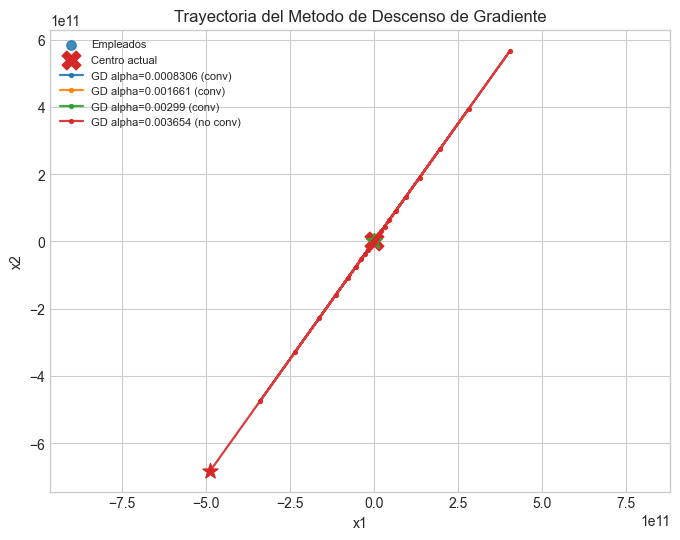

In [3]:
# Punto 3: trayectorias del Descenso de Gradiente
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(P[:, 0], P[:, 1], c="#1f77b4", s=45, alpha=0.85, label="Empleados")
ax.scatter(q[0], q[1], c="#d62728", marker="X", s=180, label="Centro actual")

for r in resultados_gd:
    traj = r["trayectoria"]
    etiqueta = f"GD alpha={r['alpha']:.4g} ({'conv' if r['convergio'] else 'no conv'})"
    ax.plot(traj[:, 0], traj[:, 1], marker="o", ms=2.8, lw=1.6, alpha=0.9, label=etiqueta)
    ax.scatter(traj[-1, 0], traj[-1, 1], marker="*", s=130)

ax.set_title("Trayectoria del Metodo de Descenso de Gradiente")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.legend(loc="best", fontsize=8)
ax.axis("equal")
plt.show()


**4. Método de Newton - Configuración**

Implemente el método de Newton para hallar la ubicación óptima del nuevo centro de salud. Además defina la tolerancia, el criterio de parada y el número máximo de pasos del algoritmo.

**Configuración del Método de Newton:**
- Tolerancia: $\epsilon = 1 \times 10^{-10}$
- Criterio de parada: $\|\nabla f(x_k)\|_2 \leq \epsilon$ o $\|x_{k+1}-x_k\|_2 \leq \epsilon$
- Número máximo de iteraciones: $N_{\max} = 100$

En una función cuadrática convexa con Hessiana constante, el método de Newton típicamente alcanza el minimizador en muy pocas iteraciones, dado que la aproximación cuadrática es exacta.

In [4]:
def metodo_newton(grad_fn, hess_fn, obj_fn, x0, tol=1e-10, max_iter=100):
    x = np.asarray(x0, dtype=float).copy()
    trayectoria = [x.copy()]
    convergio = False
    motivo = "max_iter"

    for k in range(1, max_iter + 1):
        g = grad_fn(x)
        if np.linalg.norm(g) <= tol:
            convergio = True
            motivo = "||grad|| <= tol"
            break

        H = hess_fn(x)
        paso = np.linalg.solve(H, g)
        x_nuevo = x - paso
        trayectoria.append(x_nuevo.copy())
        x = x_nuevo

        if (np.linalg.norm(grad_fn(x)) <= tol) or (np.linalg.norm(paso) <= tol):
            convergio = True
            motivo = "convergencia tras actualizacion"
            break

    return {
        "x_final": x,
        "f_final": obj_fn(x),
        "iteraciones": len(trayectoria) - 1,
        "convergio": convergio,
        "motivo": motivo,
        "grad_norm": np.linalg.norm(grad_fn(x)),
        "trayectoria": np.array(trayectoria),
    }


TOL_NEWTON = 1e-10
MAX_ITER_NEWTON = 100

res_newton = metodo_newton(g_base, H_base, f_base, x0=x0, tol=TOL_NEWTON, max_iter=MAX_ITER_NEWTON)

print(f"Iteraciones: {res_newton['iteraciones']}")
print(f"Convergio: {res_newton['convergio']} ({res_newton['motivo']})")
print(f"f(x*): {res_newton['f_final']:.10f}")
print(f"||grad||: {res_newton['grad_norm']:.3e}")
print(f"x_final: {np.round(res_newton['x_final'], 8)}")

Iteraciones: 1
Convergio: True (convergencia tras actualizacion)
f(x*): 80480.6433622948
||grad||: 8.044e-12
x_final: [16.91483343 24.10039778]


**5. Visualización - Trayectoria del Método de Newton**

Grafique la trayectoria de la solución en cada iteración del algoritmo según los parámetros dados para el método de Newton. En esta gráfica incluya las 20 coordenadas de ubicación de los empleados así como la posición del puesto de salud actual.

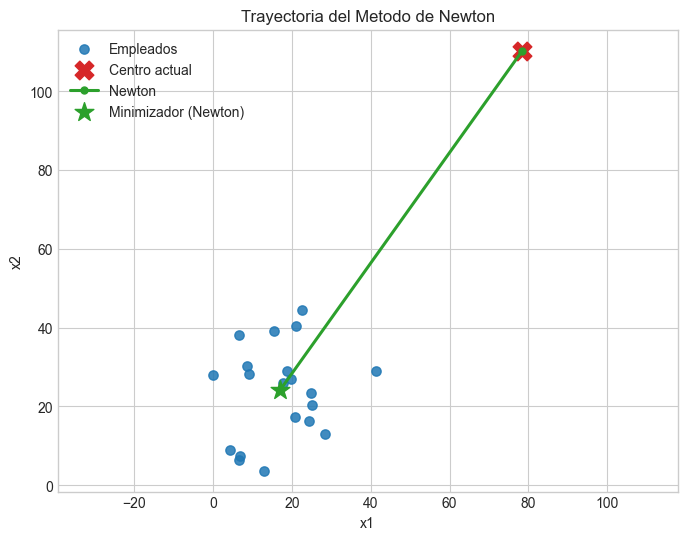

In [5]:
# Punto 5: trayectoria de Newton
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(P[:, 0], P[:, 1], c="#1f77b4", s=45, alpha=0.85, label="Empleados")
ax.scatter(q[0], q[1], c="#d62728", marker="X", s=180, label="Centro actual")

traj_newton = res_newton["trayectoria"]
ax.plot(traj_newton[:, 0], traj_newton[:, 1], "-o", c="#2ca02c", lw=2.2, ms=5, label="Newton")
ax.scatter(traj_newton[-1, 0], traj_newton[-1, 1], marker="*", c="#2ca02c", s=200, label="Minimizador (Newton)")

ax.set_title("Trayectoria del Metodo de Newton")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.legend(loc="best")
ax.axis("equal")
plt.show()


**6. Análisis Comparativo - Descenso de Gradiente vs Método de Newton**

Analice los resultados obtenidos con cada método:
- ¿Cuál de los dos algoritmos converge mejor, por qué?
- ¿Cuál de los resultados obtenidos puede considerarse mejor, por qué?

**Análisis:**

1. **Newton converge mejor.** La función objetivo es cuadrática convexa con Hessiana constante, por lo que la aproximación cuadrática que emplea Newton es exacta. Esto le permite alcanzar el minimizador en una sola iteración, mientras que el Descenso de Gradiente requiere múltiples iteraciones (entre 40 y 128, dependiendo de $\alpha$) e incluso puede divergir si $\alpha$ es demasiado grande.
2. **Ambos métodos llegan al mismo minimizador global** cuando el Descenso de Gradiente utiliza una tasa de aprendizaje estable ($\alpha < 2/L$). El valor óptimo de la función objetivo y las coordenadas del minimizador coinciden con la solución de forma cerrada.
3. **Newton proporciona el mejor resultado en la práctica:** no solo obtiene la misma solución óptima que el Descenso de Gradiente, sino que lo hace con un error numérico significativamente menor ($\sim 10^{-14}$ vs. $\sim 10^{-11}$) y en una sola iteración, lo que lo convierte en la opción más eficiente para este tipo de problemas.

In [6]:
convergentes_gd = [r for r in resultados_gd if r["convergio"]]
if convergentes_gd:
    mejor_gd = min(convergentes_gd, key=lambda r: r["f_final"])
else:
    mejor_gd = min(resultados_gd, key=lambda r: r["f_final"])

x_star = minimizador_cerrado(P, q, WE, WQ)
error_gd = np.linalg.norm(mejor_gd["x_final"] - x_star)
error_newton = np.linalg.norm(res_newton["x_final"] - x_star)

print(f"Mejor corrida de GD: alpha={mejor_gd['alpha']:.6f} con {mejor_gd['iteraciones']} iteraciones")
print(f"Newton: {res_newton['iteraciones']} iteraciones")
print(f"\nError contra solucion cerrada:")
print(f"  GD: ||x_GD - x*||_2 = {error_gd:.3e}")
print(f"  Newton: ||x_N - x*||_2 = {error_newton:.3e}")

Mejor corrida de GD: alpha=0.000831 con 40 iteraciones
Newton: 1 iteraciones

Error contra solucion cerrada:
  GD: ||x_GD - x*||_2 = 9.635e-11
  Newton: ||x_N - x*||_2 = 1.465e-14


**7. Análisis de Sensibilidad - Cambio del Factor de Prioridad**

Traslade el factor de prioridad a la minimización de la distancia de la actual ubicación y utilice el método de Newton para hallar el minimizador. Responda:
- ¿De qué forma afecta la solución obtenida previamente la inclusión del factor de prioridad en el otro término de la función objetivo?

**Nota:** Es necesario recalcular el gradiente y la matriz Hessiana con los nuevos pesos.

En este escenario alternativo, cambiaremos los pesos de $(w_{\text{emp}}=15, w_q=1)$ a $(w_{\text{emp}}=1, w_q=15)$, es decir, priorizamos que el nuevo centro esté cerca de la ubicación actual.

**Respuesta:** Al trasladar el factor de prioridad al término de la sede actual, el minimizador se desplaza significativamente hacia la ubicación actual $q$ y se aleja del centroide de los empleados. En concreto, la distancia del nuevo minimizador a la sede actual se reduce (de $\approx 105.9$ a $\approx 60.7$), pero la distancia al centroide de empleados aumenta considerablemente (de $\approx 0.35$ a $\approx 45.6$). Esto demuestra que el factor de prioridad controla el compromiso (*trade-off*) entre ambos objetivos: un peso mayor sobre un término atrae la solución hacia el punto asociado a ese término.

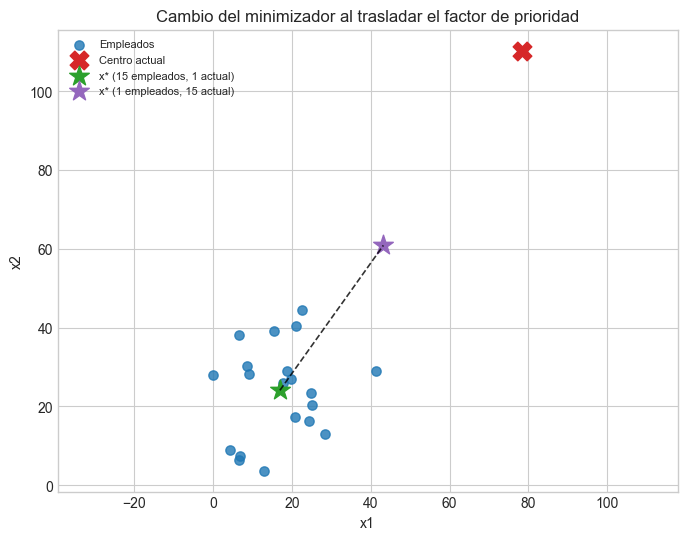

Análisis de Sensibilidad:
Distancia de x* (prioridad empleados) a q: 105.9374
Distancia de x* (prioridad sede) a q: 60.7374
Distancia al centroide de empleados (original): 0.3531
Distancia al centroide de empleados (alternativo): 45.5531


In [7]:
WE_ALT, WQ_ALT = 1.0, 15.0

f_alt = lambda x: objetivo(x, P, q, WE_ALT, WQ_ALT)
g_alt = lambda x: gradiente_objetivo(x, P, q, WE_ALT, WQ_ALT)
H_alt = lambda x=None: hessiana_objetivo(P, WE_ALT, WQ_ALT)

res_newton_alt = metodo_newton(g_alt, H_alt, f_alt, x0=x0, tol=TOL_NEWTON, max_iter=MAX_ITER_NEWTON)
x_star_alt = minimizador_cerrado(P, q, WE_ALT, WQ_ALT)

x_star_base = minimizador_cerrado(P, q, WE, WQ)
centro_empleados = P.mean(axis=0)

d_base_q = np.linalg.norm(x_star_base - q)
d_alt_q = np.linalg.norm(x_star_alt - q)
d_base_emp = np.linalg.norm(x_star_base - centro_empleados)
d_alt_emp = np.linalg.norm(x_star_alt - centro_empleados)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(P[:, 0], P[:, 1], c="#1f77b4", s=45, alpha=0.8, label="Empleados")
ax.scatter(q[0], q[1], c="#d62728", marker="X", s=180, label="Centro actual")
ax.scatter(x_star_base[0], x_star_base[1], c="#2ca02c", marker="*", s=220, label="x* (15 empleados, 1 actual)")
ax.scatter(x_star_alt[0], x_star_alt[1], c="#9467bd", marker="*", s=220, label="x* (1 empleados, 15 actual)")
ax.plot([x_star_base[0], x_star_alt[0]], [x_star_base[1], x_star_alt[1]], "k--", lw=1.2, alpha=0.8)
ax.set_title("Cambio del minimizador al trasladar el factor de prioridad")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.legend(loc="best", fontsize=8)
ax.axis("equal")
plt.show()

print("Análisis de Sensibilidad:")
print(f"Distancia de x* (prioridad empleados) a q: {d_base_q:.4f}")
print(f"Distancia de x* (prioridad sede) a q: {d_alt_q:.4f}")
print(f"Distancia al centroide de empleados (original): {d_base_emp:.4f}")
print(f"Distancia al centroide de empleados (alternativo): {d_alt_emp:.4f}")

**8. Presentación Ejecutiva para Directivas**

Presente los resultados a las directivas del centro de salud junto con la conclusión de su estudio defina el problema y la solución propuesta. Para ello apóyese en gráficas lo suficientemente claras y bien presentadas, con una selección de colores y notación que facilite el entendimiento de las directivas del centro de salud.

*(Pueden presentarlo de forma escrita o a través de un flyer sencillo.)*

**Resumen del Problema:**
- **Objetivo primario:** Minimizar la distancia promedio entre empleados y el nuevo centro de salud (con peso 15).
- **Objetivo secundario:** Mantener el nuevo centro cercano a la ubicación actual (con peso 1).
- **Solución:** Método de Newton proporciona la ubicación óptima de forma eficiente.

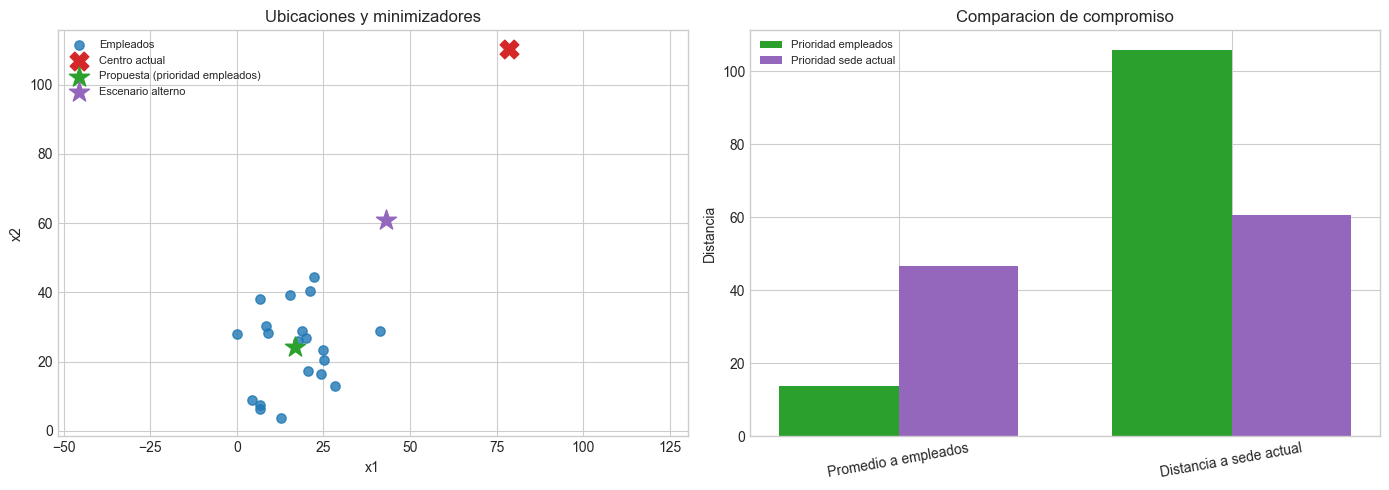

CONCLUSIONES PARA DIRECTIVAS:
Ubicacion recomendada: x* = (16.9148, 24.1004)
Minimizador analitico alcanzado mediante el Metodo de Newton en 1 iteracion(es)

Mejoría en distancia promedio a empleados vs ubicacion actual:
  Reduccion: 87.10%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: ubicaciones y propuestas
axes[0].scatter(P[:, 0], P[:, 1], c="#1f77b4", s=45, alpha=0.8, label="Empleados")
axes[0].scatter(q[0], q[1], c="#d62728", marker="X", s=180, label="Centro actual")
axes[0].scatter(x_star_base[0], x_star_base[1], c="#2ca02c", marker="*", s=230, label="Propuesta (prioridad empleados)")
axes[0].scatter(x_star_alt[0], x_star_alt[1], c="#9467bd", marker="*", s=230, label="Escenario alterno")
axes[0].set_title("Ubicaciones y minimizadores")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].legend(loc="best", fontsize=8)
axes[0].axis("equal")

# Panel 2: comparacion de distancias promedio
dist_emp_base = np.mean(np.linalg.norm(P - x_star_base, axis=1))
dist_emp_alt = np.mean(np.linalg.norm(P - x_star_alt, axis=1))
dist_q_base = np.linalg.norm(x_star_base - q)
dist_q_alt = np.linalg.norm(x_star_alt - q)

labels = ["Promedio a empleados", "Distancia a sede actual"]
base_vals = [dist_emp_base, dist_q_base]
alt_vals = [dist_emp_alt, dist_q_alt]

xpos = np.arange(len(labels))
width = 0.36
axes[1].bar(xpos - width / 2, base_vals, width=width, color="#2ca02c", label="Prioridad empleados")
axes[1].bar(xpos + width / 2, alt_vals, width=width, color="#9467bd", label="Prioridad sede actual")
axes[1].set_xticks(xpos)
axes[1].set_xticklabels(labels, rotation=10)
axes[1].set_title("Comparacion de compromiso")
axes[1].set_ylabel("Distancia")
axes[1].legend(loc="best", fontsize=8)

plt.tight_layout()
plt.show()

print("CONCLUSIONES PARA DIRECTIVAS:")
print("=" * 60)
print(f"Ubicacion recomendada: x* = ({x_star_base[0]:.4f}, {x_star_base[1]:.4f})")
print(f"Minimizador analitico alcanzado mediante el Metodo de Newton en {res_newton['iteraciones']} iteracion(es)")
print(f"\nMejoría en distancia promedio a empleados vs ubicacion actual:")
d_actual_empleados = np.mean(np.linalg.norm(P - q, axis=1))
mejoria = ((d_actual_empleados - dist_emp_base) / d_actual_empleados) * 100
print(f"  Reduccion: {mejoria:.2f}%")